<a href="https://colab.research.google.com/github/Raboooiii/Sem6/blob/main/SC/MOOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  Weighted Sum Method - Pareto Front Approximation
  Objectives  : 2
  Weight steps: 25

  Run 01: [w1=0.00 w2=1.00]  ->  f1=9.0023 | f2=2.0000
  Run 02: [w1=0.04 w2=0.96]  ->  f1=8.3472 | f2=2.0139
  Run 03: [w1=0.08 w2=0.92]  ->  f1=7.7222 | f2=2.0556
  Run 04: [w1=0.12 w2=0.88]  ->  f1=7.1250 | f2=2.1250
  Run 05: [w1=0.17 w2=0.83]  ->  f1=6.5556 | f2=2.2222
  Run 06: [w1=0.21 w2=0.79]  ->  f1=6.0139 | f2=2.3472
  Run 07: [w1=0.25 w2=0.75]  ->  f1=5.5000 | f2=2.5000
  Run 08: [w1=0.29 w2=0.71]  ->  f1=5.0139 | f2=2.6806
  Run 09: [w1=0.33 w2=0.67]  ->  f1=4.5556 | f2=2.8889
  Run 10: [w1=0.38 w2=0.62]  ->  f1=4.1250 | f2=3.1250
  Run 11: [w1=0.42 w2=0.58]  ->  f1=3.7222 | f2=3.3889
  Run 12: [w1=0.46 w2=0.54]  ->  f1=3.3472 | f2=3.6806
  Run 13: [w1=0.50 w2=0.50]  ->  f1=3.0000 | f2=4.0000
  Run 14: [w1=0.54 w2=0.46]  ->  f1=2.6806 | f2=4.3472
  Run 15: [w1=0.58 w2=0.42]  ->  f1=2.3889 | f2=4.7222
  Run 16: [w1=0.62 w2=0.38]  ->  f1=2.1250 | f2=5.1250
  Run 17: [w1=0.67 w2=0.33]  -

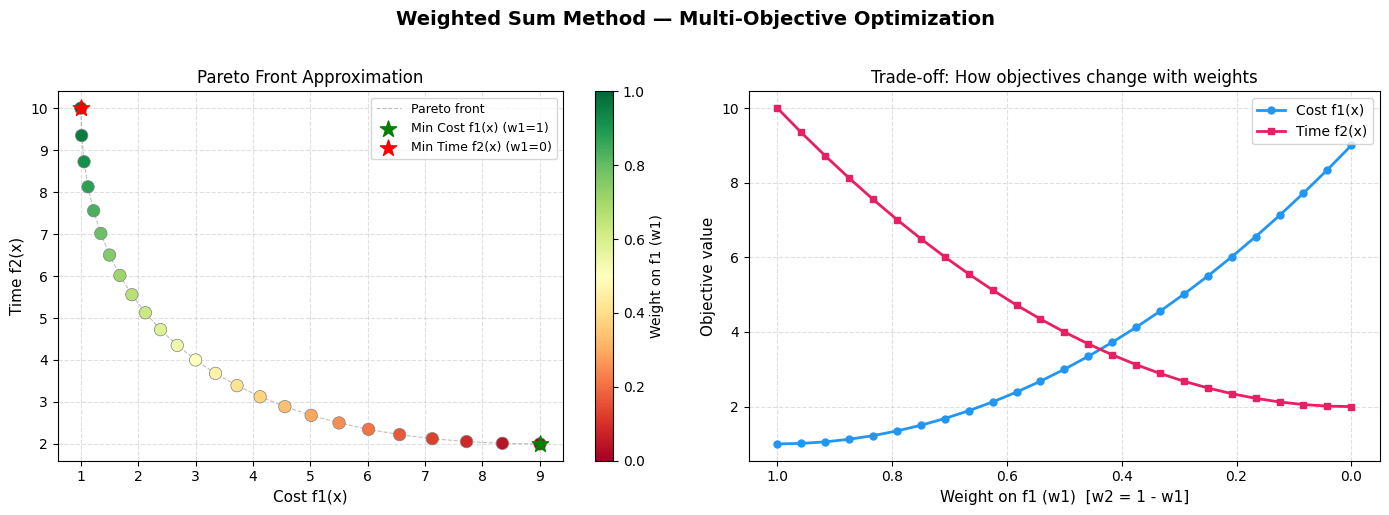

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
import os
warnings.filterwarnings("ignore")


# =============================================================================
# STEP 1: DEFINE YOUR OBJECTIVE FUNCTIONS
# =============================================================================
# Example MOOP: Minimize BOTH cost AND time for a manufacturing process
# f1(x) = Cost     -> we want to MINIMIZE
# f2(x) = Time     -> we want to MINIMIZE
# x = [x1, x2]  where x1, x2 are decision variables (e.g. machine speed, batch size)

def f1_cost(x):
    """Objective 1: Minimize cost (cheaper is better)"""
    x1, x2 = x
    return (x1 - 2)**2 + (x2 - 1)**2 + 1

def f2_time(x):
    """Objective 2: Minimize time (faster is better)"""
    x1, x2 = x
    return (x1 - 4)**2 + (x2 - 3)**2 + 2


# =============================================================================
# STEP 2: WEIGHTED SUM FUNCTION
# =============================================================================

def weighted_sum(x, weights, objectives):
    """
    Combines all objectives into one scalar using weights.

    Parameters:
        x         : decision variable vector
        weights   : list of weights [w1, w2, ...], must sum to 1
        objectives: list of objective functions [f1, f2, ...]

    Returns:
        scalar value (the combined weighted objective)
    """
    total = 0.0
    for w, f in zip(weights, objectives):
        total += w * f(x)
    return total


# =============================================================================
# STEP 3: SOLVE FOR A SINGLE WEIGHT COMBINATION
# =============================================================================

def solve_single(weights, objectives, x0, bounds=None):
    """
    Solves the weighted sum problem for one set of weights.

    Parameters:
        weights   : weight vector [w1, w2, ...]
        objectives: list of objective functions
        x0        : initial guess for decision variables
        bounds    : variable bounds e.g. [(0,5), (0,5)]

    Returns:
        dict with solution details
    """
    result = minimize(
        fun=weighted_sum,
        x0=x0,
        args=(weights, objectives),
        method='SLSQP',
        bounds=bounds
    )

    if result.success:
        x_opt = result.x
        obj_values = [f(x_opt) for f in objectives]
        return {
            'x': x_opt,
            'objectives': obj_values,
            'weighted_sum': result.fun,
            'weights': weights,
            'success': True
        }
    else:
        return {'success': False, 'weights': weights}


# =============================================================================
# STEP 4: GENERATE PARETO FRONT APPROXIMATION
# =============================================================================

def generate_pareto_front(objectives, x0, bounds=None, num_points=20):
    """
    Sweeps weight combinations to approximate the Pareto front.

    For 2 objectives: w1 goes from 0 to 1, w2 = 1 - w1
    For more objectives: uses random weight sampling

    Parameters:
        objectives : list of objective functions
        x0         : initial guess
        bounds     : variable bounds
        num_points : number of weight combinations to try

    Returns:
        list of successful solution dicts
    """
    num_objectives = len(objectives)
    pareto_solutions = []

    print(f"\n{'='*55}")
    print(f"  Weighted Sum Method - Pareto Front Approximation")
    print(f"{'='*55}")
    print(f"  Objectives  : {num_objectives}")
    print(f"  Weight steps: {num_points}")
    print(f"{'='*55}\n")

    if num_objectives == 2:
        # For 2 objectives: sweep w1 from 0 to 1
        weight_values = np.linspace(0, 1, num_points)
        weight_sets = [[w, 1 - w] for w in weight_values]
    else:
        # For 3+ objectives: random weight sampling (Dirichlet distribution)
        weight_sets = np.random.dirichlet(np.ones(num_objectives), size=num_points)

    for i, weights in enumerate(weight_sets):
        sol = solve_single(weights, objectives, x0, bounds)
        if sol['success']:
            pareto_solutions.append(sol)
            f_vals = " | ".join([f"f{j+1}={v:.4f}" for j, v in enumerate(sol['objectives'])])
            w_vals = " ".join([f"w{j+1}={w:.2f}" for j, w in enumerate(weights)])
            print(f"  Run {i+1:02d}: [{w_vals}]  ->  {f_vals}")

    print(f"\n  Total successful solutions: {len(pareto_solutions)}/{num_points}")
    return pareto_solutions


# =============================================================================
# STEP 5: PLOT THE PARETO FRONT (2 Objectives)
# =============================================================================

def plot_pareto_front_2d(solutions, obj_names=None):
    """
    Plots the Pareto front for a 2-objective problem.

    Parameters:
        solutions : list of solution dicts from generate_pareto_front()
        obj_names : list of axis labels e.g. ['Cost', 'Time']
    """
    if obj_names is None:
        obj_names = ['Objective 1', 'Objective 2']

    f1_vals = [s['objectives'][0] for s in solutions]
    f2_vals = [s['objectives'][1] for s in solutions]
    weights = [s['weights'][0] for s in solutions]   # w1 for color mapping

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Weighted Sum Method — Multi-Objective Optimization',
                 fontsize=14, fontweight='bold', y=1.02)

    # --- Plot 1: Pareto Front ---
    ax1 = axes[0]
    sc = ax1.scatter(f1_vals, f2_vals, c=weights, cmap='RdYlGn',
                     s=80, edgecolors='gray', linewidths=0.5, zorder=3)
    ax1.plot(f1_vals, f2_vals, '--', color='gray', linewidth=0.8,
             alpha=0.5, label='Pareto front', zorder=2)

    # Annotate extremes
    ax1.scatter(f1_vals[0],  f2_vals[0],  s=150, marker='*',
                color='green', zorder=4, label=f'Min {obj_names[0]} (w1=1)')
    ax1.scatter(f1_vals[-1], f2_vals[-1], s=150, marker='*',
                color='red',   zorder=4, label=f'Min {obj_names[1]} (w1=0)')

    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label('Weight on f1 (w1)', fontsize=10)
    ax1.set_xlabel(obj_names[0], fontsize=11)
    ax1.set_ylabel(obj_names[1], fontsize=11)
    ax1.set_title('Pareto Front Approximation', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # --- Plot 2: Trade-off curve (w1 vs each objective) ---
    ax2 = axes[1]
    ax2.plot(weights, f1_vals, 'o-', color='#2196F3', linewidth=2,
             markersize=5, label=obj_names[0])
    ax2.plot(weights, f2_vals, 's-', color='#E91E63', linewidth=2,
             markersize=5, label=obj_names[1])
    ax2.set_xlabel('Weight on f1 (w1)  [w2 = 1 - w1]', fontsize=11)
    ax2.set_ylabel('Objective value', fontsize=11)
    ax2.set_title('Trade-off: How objectives change with weights', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.invert_xaxis()   # w1=1 (prefer f1) on left, w1=0 (prefer f2) on right

    plt.tight_layout()
    output_dir = '/mnt/user-data/outputs/'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, 'pareto_front.png'), dpi=150, bbox_inches='tight')
    print("\n  Plot saved: pareto_front.png")
    plt.show()


# =============================================================================
# STEP 6: PICK THE BEST SOLUTION BY USER PREFERENCE
# =============================================================================

def pick_best_solution(solutions, preference_weights):
    """
    From all Pareto-optimal solutions, pick the one that best matches
    the decision-maker's preference using weighted scoring.

    Parameters:
        solutions          : list of solution dicts
        preference_weights : importance weights for each objective
                             e.g. [0.7, 0.3] means "prefer minimizing f1"

    Returns:
        best solution dict
    """
    # Normalize each objective to [0,1] range for fair comparison
    num_obj = len(solutions[0]['objectives'])
    obj_matrix = np.array([s['objectives'] for s in solutions])

    obj_min = obj_matrix.min(axis=0)
    obj_max = obj_matrix.max(axis=0)
    obj_range = obj_max - obj_min
    obj_range[obj_range == 0] = 1   # avoid divide by zero

    normalized = (obj_matrix - obj_min) / obj_range

    # Score each solution: lower is better
    scores = normalized @ np.array(preference_weights)
    best_idx = np.argmin(scores)

    return solutions[best_idx]


# =============================================================================
# MAIN — RUN EVERYTHING
# =============================================================================

if __name__ == "__main__":

    # --- Problem Setup ---
    objectives = [f1_cost, f2_time]          # list of objective functions
    x0         = [1.0, 1.0]                  # initial guess (starting point)
    bounds     = [(0, 6), (0, 6)]            # variable bounds: 0 <= x1,x2 <= 6
    obj_names  = ['Cost f1(x)', 'Time f2(x)']

    # --- Generate Pareto Front ---
    solutions = generate_pareto_front(
        objectives=objectives,
        x0=x0,
        bounds=bounds,
        num_points=25
    )

    # --- Print Summary Table ---
    print(f"\n{'='*65}")
    print(f"  {'#':<4} {'w1':>6} {'w2':>6} {'f1 (Cost)':>12} {'f2 (Time)':>12} {'x1':>8} {'x2':>8}")
    print(f"  {'-'*61}")
    for i, s in enumerate(solutions):
        print(f"  {i+1:<4} {s['weights'][0]:>6.2f} {s['weights'][1]:>6.2f} "
              f"{s['objectives'][0]:>12.4f} {s['objectives'][1]:>12.4f} "
              f"{s['x'][0]:>8.4f} {s['x'][1]:>8.4f}")
    print(f"{'='*65}")

    # --- Decision Maker: pick best solution ---
    # Example: I care 60% about cost, 40% about time
    my_preference = [0.6, 0.4]
    best = pick_best_solution(solutions, my_preference)

    print(f"\n  Decision Maker Preference: w_cost={my_preference[0]}, w_time={my_preference[1]}")
    print(f"\n  >>> Best solution for your preference:")
    print(f"      x1 = {best['x'][0]:.4f}, x2 = {best['x'][1]:.4f}")
    print(f"      Cost (f1) = {best['objectives'][0]:.4f}")
    print(f"      Time (f2) = {best['objectives'][1]:.4f}")
    print(f"      Weights used: w1={best['weights'][0]:.2f}, w2={best['weights'][1]:.2f}")

    # --- Plot ---
    plot_pareto_front_2d(solutions, obj_names)


# =============================================================================
# HOW TO CUSTOMIZE FOR YOUR OWN PROBLEM
# =============================================================================
# 1. Replace f1_cost() and f2_time() with your own objective functions.
# 2. Update x0 with a reasonable starting point for your variables.
# 3. Update bounds to match your variable ranges.
# 4. Change obj_names for better axis labels.
# 5. Change num_points to get more (denser) or fewer Pareto solutions.
# 6. Update my_preference to reflect your priorities.
#
# For 3 objectives: just add f3() to the objectives list —
# the code handles it automatically using random weight sampling.